In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
d1 = pd.read_csv("HousePricePrediction (1).csv")
d1

df=pd.read_csv("HousePricePrediction (1).csv")

In [3]:
d1.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [4]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [5]:
col = ["MSZoning","LotConfig","Exterior1st","BldgType"]
col

['MSZoning', 'LotConfig', 'Exterior1st', 'BldgType']

In [6]:
d1[col]

,MSZoning,LotConfig,Exterior1st,BldgType
0,RL,Inside,VinylSd,1Fam
1,RL,FR2,MetalSd,1Fam
2,RL,Inside,VinylSd,1Fam
3,RL,Corner,Wd Sdng,1Fam
4,RL,FR2,VinylSd,1Fam
...,...,...,...,...
2914,RM,Inside,CemntBd,Twnhs
2915,RM,Inside,CemntBd,TwnhsE
2916,RL,Inside,VinylSd,1Fam
2917,RL,Inside,HdBoard,1Fam


In [7]:
from sklearn.preprocessing import OneHotEncoder
# Run this when you are starting fresh with your original df
cat_cols = d1.select_dtypes(include='object').columns

d1 = pd.get_dummies(d1, columns=cat_cols, drop_first=True)
d1

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,False,...,False,False,False,False,False,False,False,True,False,False
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,False,...,False,False,False,True,False,False,False,False,False,False
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,False,...,False,False,False,False,False,False,False,True,False,False
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,False,...,False,False,False,False,False,False,False,False,True,False
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,1936,7,1970,1970,0.0,546.0,NaN,False,...,True,False,False,False,False,False,False,False,False,False
2915,2915,160,1894,5,1970,1970,0.0,546.0,NaN,False,...,True,False,False,False,False,False,False,False,False,False
2916,2916,20,20000,7,1960,1996,0.0,1224.0,NaN,False,...,False,False,False,False,False,False,False,True,False,False
2917,2917,85,10441,5,1992,1992,0.0,912.0,NaN,False,...,False,True,False,False,False,False,False,False,False,False


In [8]:
# Option 2 — convert only boolean columns
bool_cols = d1.select_dtypes(include='bool').columns
d1[bool_cols] = d1[bool_cols].astype(int)

print(d1.shape)
d1.head()

(2919, 35)


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,...,0,0,0,0,0,0,0,1,0,0


In [9]:
d1

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,1936,7,1970,1970,0.0,546.0,NaN,0,...,1,0,0,0,0,0,0,0,0,0
2915,2915,160,1894,5,1970,1970,0.0,546.0,NaN,0,...,1,0,0,0,0,0,0,0,0,0
2916,2916,20,20000,7,1960,1996,0.0,1224.0,NaN,0,...,0,0,0,0,0,0,0,1,0,0
2917,2917,85,10441,5,1992,1992,0.0,912.0,NaN,0,...,0,1,0,0,0,0,0,0,0,0


In [10]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2919 non-null   int64  
 1   MSSubClass           2919 non-null   int64  
 2   LotArea              2919 non-null   int64  
 3   OverallCond          2919 non-null   int64  
 4   YearBuilt            2919 non-null   int64  
 5   YearRemodAdd         2919 non-null   int64  
 6   BsmtFinSF2           2918 non-null   float64
 7   TotalBsmtSF          2918 non-null   float64
 8   SalePrice            1460 non-null   float64
 9   MSZoning_FV          2919 non-null   int32  
 10  MSZoning_RH          2919 non-null   int32  
 11  MSZoning_RL          2919 non-null   int32  
 12  MSZoning_RM          2919 non-null   int32  
 13  LotConfig_CulDSac    2919 non-null   int32  
 14  LotConfig_FR2        2919 non-null   int32  
 15  LotConfig_FR3        2919 non-null   i

In [11]:
d1.isnull().sum()

Id                        0
MSSubClass                0
LotArea                   0
OverallCond               0
YearBuilt                 0
YearRemodAdd              0
BsmtFinSF2                1
TotalBsmtSF               1
SalePrice              1459
MSZoning_FV               0
MSZoning_RH               0
MSZoning_RL               0
MSZoning_RM               0
LotConfig_CulDSac         0
LotConfig_FR2             0
LotConfig_FR3             0
LotConfig_Inside          0
BldgType_2fmCon           0
BldgType_Duplex           0
BldgType_Twnhs            0
BldgType_TwnhsE           0
Exterior1st_AsphShn       0
Exterior1st_BrkComm       0
Exterior1st_BrkFace       0
Exterior1st_CBlock        0
Exterior1st_CemntBd       0
Exterior1st_HdBoard       0
Exterior1st_ImStucc       0
Exterior1st_MetalSd       0
Exterior1st_Plywood       0
Exterior1st_Stone         0
Exterior1st_Stucco        0
Exterior1st_VinylSd       0
Exterior1st_Wd Sdng       0
Exterior1st_WdShing       0
dtype: int64

In [12]:
num_col = ["SalePrice"]


In [13]:
from sklearn.impute import SimpleImputer

num_fill = SimpleImputer(strategy='mean')
d1[num_col] = num_fill.fit_transform(d1[num_col])
d1.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,...,0,0,0,0,0,0,0,1,0,0


In [14]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2919 non-null   int64  
 1   MSSubClass           2919 non-null   int64  
 2   LotArea              2919 non-null   int64  
 3   OverallCond          2919 non-null   int64  
 4   YearBuilt            2919 non-null   int64  
 5   YearRemodAdd         2919 non-null   int64  
 6   BsmtFinSF2           2918 non-null   float64
 7   TotalBsmtSF          2918 non-null   float64
 8   SalePrice            2919 non-null   float64
 9   MSZoning_FV          2919 non-null   int32  
 10  MSZoning_RH          2919 non-null   int32  
 11  MSZoning_RL          2919 non-null   int32  
 12  MSZoning_RM          2919 non-null   int32  
 13  LotConfig_CulDSac    2919 non-null   int32  
 14  LotConfig_FR2        2919 non-null   int32  
 15  LotConfig_FR3        2919 non-null   i

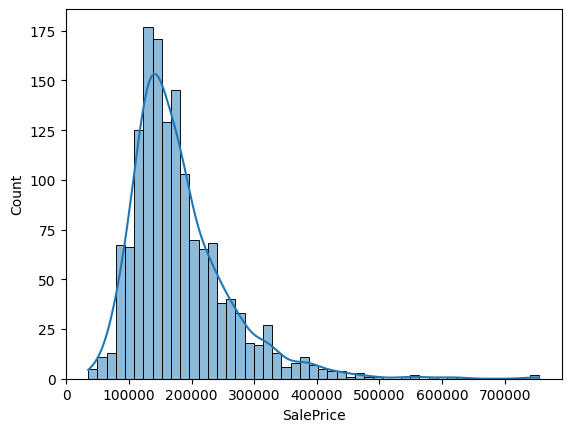

In [15]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()
# outliers are there ok 500k,600k to remove that  use log to get bell curve


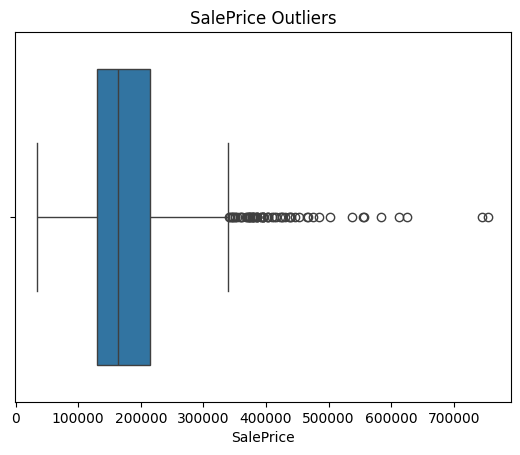

In [16]:
# visulaize how many outliers are ther of box plot
sns.boxplot(x=df['SalePrice'])
plt.title('SalePrice Outliers')
plt.show()
# The dots on the right = outliers ✅

In [17]:
# Check how many outliers exist
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

outliers = df[(df['SalePrice'] > upper) | (df['SalePrice'] < lower)]
print("Number of outliers:", len(outliers))
print("Upper limit:", upper)
print("Lower limit:", lower)

Number of outliers: 61
Upper limit: 340037.5
Lower limit: 3937.5


In [18]:
df_clean = df[(df['SalePrice'] <= upper) & (df['SalePrice'] >= lower)]
print("Shape before:", df.shape)
print("Shape after:", df_clean.shape)

Shape before: (2919, 13)
Shape after: (1399, 13)


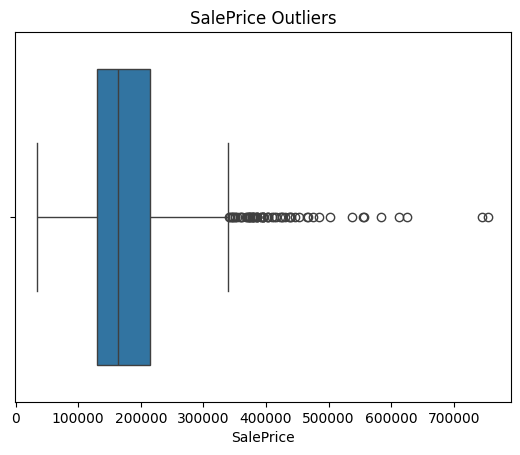

In [19]:
sns.boxplot(x=df['SalePrice'])
plt.title('SalePrice Outliers')
plt.show()
#outliers are improved some  after the chnaging distribution


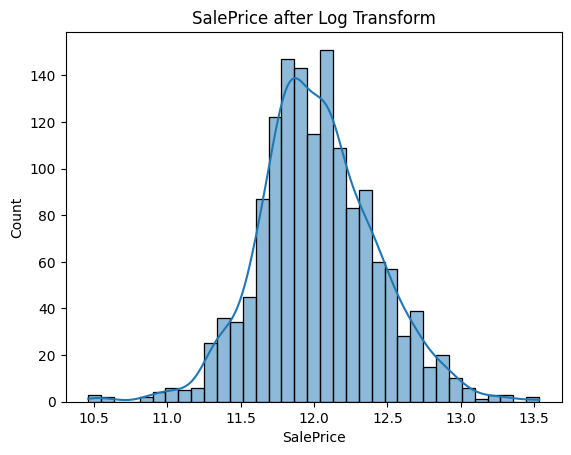

In [20]:
#log transfrom
import numpy as np
df['SalePrice'] = np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice after Log Transform')
plt.show()

In [21]:
d1.isnull().sum()

Id                     0
MSSubClass             0
LotArea                0
OverallCond            0
YearBuilt              0
YearRemodAdd           0
BsmtFinSF2             1
TotalBsmtSF            1
SalePrice              0
MSZoning_FV            0
MSZoning_RH            0
MSZoning_RL            0
MSZoning_RM            0
LotConfig_CulDSac      0
LotConfig_FR2          0
LotConfig_FR3          0
LotConfig_Inside       0
BldgType_2fmCon        0
BldgType_Duplex        0
BldgType_Twnhs         0
BldgType_TwnhsE        0
Exterior1st_AsphShn    0
Exterior1st_BrkComm    0
Exterior1st_BrkFace    0
Exterior1st_CBlock     0
Exterior1st_CemntBd    0
Exterior1st_HdBoard    0
Exterior1st_ImStucc    0
Exterior1st_MetalSd    0
Exterior1st_Plywood    0
Exterior1st_Stone      0
Exterior1st_Stucco     0
Exterior1st_VinylSd    0
Exterior1st_Wd Sdng    0
Exterior1st_WdShing    0
dtype: int64

In [26]:
c=["BsmtFinSF2","TotalBsmtSF"]

num_fill = SimpleImputer(strategy='mean')
d1[c] = num_fill.fit_transform(d1[c])
d1.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,...,0,0,0,0,0,0,0,1,0,0


In [27]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2919 non-null   int64  
 1   MSSubClass           2919 non-null   int64  
 2   LotArea              2919 non-null   int64  
 3   OverallCond          2919 non-null   int64  
 4   YearBuilt            2919 non-null   int64  
 5   YearRemodAdd         2919 non-null   int64  
 6   BsmtFinSF2           2919 non-null   float64
 7   TotalBsmtSF          2919 non-null   float64
 8   SalePrice            2919 non-null   float64
 9   MSZoning_FV          2919 non-null   int32  
 10  MSZoning_RH          2919 non-null   int32  
 11  MSZoning_RL          2919 non-null   int32  
 12  MSZoning_RM          2919 non-null   int32  
 13  LotConfig_CulDSac    2919 non-null   int32  
 14  LotConfig_FR2        2919 non-null   int32  
 15  LotConfig_FR3        2919 non-null   i

In [28]:
#spliting the i/p and o/p
X = d1.drop("SalePrice" , axis = 1)
y = d1["SalePrice"]

#train test
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42)


In [35]:
# now training data, of using 3 models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=500,   
    max_depth=20,        
    min_samples_split=3, 
    random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)



In [36]:
#evaltion metrics

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    'Linear Regression': lr_pred,
    'Ridge Regression':  ridge_pred,
    'Random Forest':     rf_pred
}

print(f"{'Model':25} {'R²':>8} {'RMSE':>12} {'MAE':>12}")
for name, pred in models.items():
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    print(f"{name:25} {r2:>8.4f} {rmse:>12,.0f} {mae:>12,.0f}")

Model                           R²         RMSE          MAE
Linear Regression           0.3367       48,641       32,609
Ridge Regression            0.3315       48,828       32,541
Random Forest               0.7812       27,937       12,063


In [40]:
# Check 5 different houses
import warnings
warnings.filterwarnings('ignore')
for i in [0, 5, 10, 50, 100]:
    new_house = X_test.iloc[i].values.reshape(1, -1)
    predicted = rf.predict(new_house)[0]
    actual    = y_test.iloc[i]
    diff      = abs(actual - predicted)
    print(f"House {i} → Predicted: ${predicted:}  Actual: ${actual:}  Diff: ${diff:}")

House 0 → Predicted: $180921.1958904117  Actual: $180921.19589041095  Diff: $7.566995918750763e-10
House 5 → Predicted: $289255.02721428586  Actual: $311872.0  Diff: $22616.97278571414
House 10 → Predicted: $180921.1958904117  Actual: $180921.19589041095  Diff: $7.566995918750763e-10
House 50 → Predicted: $180921.1958904117  Actual: $180921.19589041095  Diff: $7.566995918750763e-10
House 100 → Predicted: $181092.3534986309  Actual: $180921.19589041095  Diff: $171.15760821994627
